# 

Plot resolution

In [26]:
#files = [ "/data/HD6/users/brownd/ntp.mu2e.ensembleMDS1eMix1BBTriggered.MDC2020ai_perfect_v1_3.root:EventNtuple/ntuple" ]
#files = [ "/data/HD6/users/brownd/ENfrom_dig.root:EventNtupleTTMCApr//ntuple" ]
#files = [ "/data/HD6/users/brownd/Ref.CosmicCRYAllTriggeredLH.v3.root:TARe/ntuple" ]
#files = [ "/data/HD6/users/brownd/EN_MDSe1.root:EventNtuple/ntuple" ]
#files = [ "/data/HD5/users/brownd/ntp.brownd.Reflections.v4.root:TARe/ntuple" ]
#files = [ "/data/HD5/users/brownd/TARef_v6.root:TAReM/trkana" ]
files = [ "/data/HD5/users/brownd/71077187/nts.brownd.TAReflect.TARef.001202_00000000.root:TAReM/ntuple" ]

In [27]:
import os
import uproot 
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
#import tensorflow as tf
from pathlib import Path
#from skspatial.objects import Vector
print("Hello world")

Hello world


In [38]:
fit_px = []
fit_py = []
fit_pz = []
mc_down_px = []
mc_down_py = []
mc_down_pz = []
mc_up_px = []
mc_up_py = []
mc_up_pz = []
#for batch,rep in uproot.iterate(files,filter_name="/trk|trksegs|trkmcvd|trkmcsim/i",report=True):
for batch in uproot.iterate(files,filter_name="/trksegs|trkmcvd|trkmcsim/i"):
#    print(repr(batch))
    print("Fields available in 'trksegs':", ak.fields(batch["trksegs"]))
    print("Fields available in 'trkmcvd':", ak.fields(batch["trkmcvd"]))
#    print("Fields available in 'trkmcsim':", ak.fields(batch["trkmcsim"]))
    trksegs_up = batch["trksegs"][:,0]
    trksegs_down = batch["trksegs"][:,1]
    print(len(trksegs_up))
    print(len(trksegs_down))
    trkmcvd_up = batch["trkmcvd"][:,0]
    trkmcvd_down = batch["trkmcvd"][:,1]
    print(len(trkmcvd_up))
    print(len(trkmcvd_down))
    trkmcsim_up = batch["trkmcsim"][:,0]
    trkmcsim_down = batch["trkmcsim"][:,1]
    print(len(trkmcsim_up))
    print(len(trkmcsim_down))
    
    ele_up = (trkmcsim_up["trkrel"]["_rel"]==0) & (trkmcsim_up["pdg"]==11)
    ele_down = (trkmcsim_down["trkrel"]["_rel"]==0) & (trkmcsim_down["pdg"]==11)
    print(trkrel_up)
    print(len(trkrel_down))
#    trkpdg = ak.flatten(trkmcsim[trkrel]["pdg"])
#    print (trkpdg,len(trkpdg))
    mc_down_mid = (trkmcvd_down["sid"] == 1) & (trkmcvd_down["mom"]["fCoordinates"]["fZ"] > 0)
    mc_up_mid = (trkmcvd_up["sid"] == 1) & (trkmcvd_up["mom"]["fCoordinates"]["fZ"] < 0)
    print(mc_down_mid)
    print(mc_up_mid)

    for itrk in range(len(trkmcvd_up)):
        for 
    
#    has_mc_down_mid = ak.sum(mc_down_mid,axis=1) > 0
    mc_down_px.extend(ak.flatten(trkmcvd_down[mc_down_mid]['mom']['fCoordinates']['fX']))
    mc_down_py.extend(ak.flatten(trkmcvd_down[mc_down_mid]['mom']['fCoordinates']['fY']))
    mc_down_pz.extend(ak.flatten(trkmcvd_down[mc_down_mid]['mom']['fCoordinates']['fZ']))
    mc_up_px.extend(ak.flatten(trkmcvd_up[mc_up_mid]['mom']['fCoordinates']['fX']))
    mc_up_py.extend(ak.flatten(trkmcvd_up[mc_up_mid]['mom']['fCoordinates']['fY']))
    mc_up_pz.extend(ak.flatten(trkmcvd_up[mc_up_mid]['mom']['fCoordinates']['fZ']))
#    trksegs = batch["trksegs"][:,0]
#    down_mid = (trksegs["sid"] == 1) & (trksegs['mom']['fCoordinates']['fZ'] > 0) # downstream mid tracker
#    has_down_mid = ak.sum(down_mid,axis=1) > 0
#    mid_px.extend(ak.flatten(trksegs[has_down_mid][down_mid]['mom']['fCoordinates']['fX']))
#    mid_py.extend(ak.flatten(trksegs[has_down_mid][down_mid]['mom']['fCoordinates']['fY']))
#    mid_pz.extend(ak.flatten(trksegs[has_down_mid][down_mid]['mom']['fCoordinates']['fZ']))
#
#print (len(mc_up_px),len(mc_down_px))
mc_down_mom2 = np.square(mc_down_px) + np.square(mc_down_py) + np.square(mc_down_pz)
mc_down_mom = np.sqrt(mc_down_mom2)
mc_up_mom2 = np.square(mc_up_px) + np.square(mc_up_py) + np.square(mc_up_pz)
mc_up_mom = np.sqrt(mc_up_mom2)
print(len(mc_up_mom))
print(len(mc_down_mom))
print(mc_up_mom[18:28])
print(mc_down_mom[18:28])
#print("mcvd mid momentum ",len(mc_mom),mc_mom[:10])

Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']
Fields available in 'trkmcvd': ['vid', 'sid', 'iinter', 'time', 'de', 'dp', 'early', 'late', 'mom', 'pos']
4086
4086
4086
4086
4086
4086
[[True, False, False], [False, False], ..., [True, ...], [True, False, False]]
4086


ValueError: cannot broadcast nested list

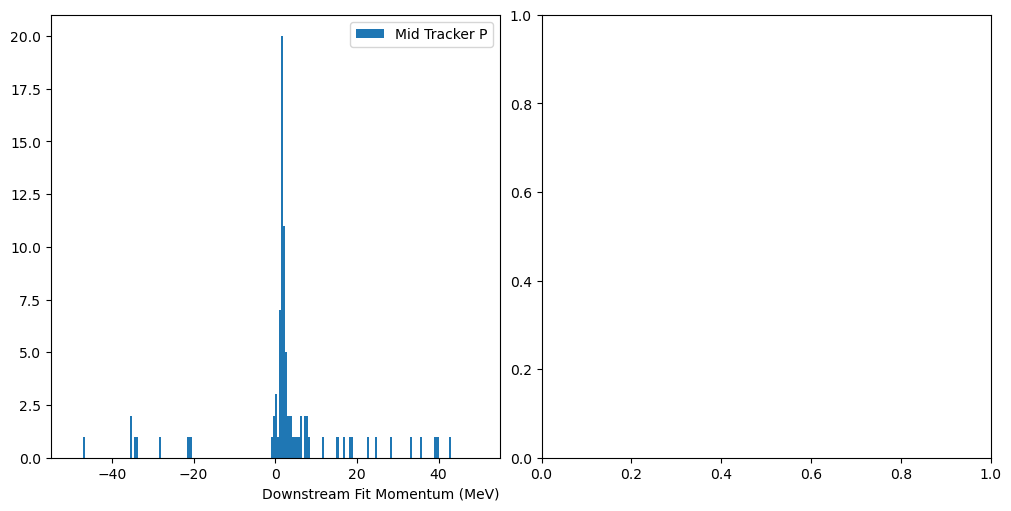

In [35]:
dpx = np.subtract(mc_up_mom, mc_down_mom)
fig, (ax0, ax1 )  = plt.subplots(1,2,layout='constrained', figsize=(10,5))
ax0.hist(dpx,label="Mid Tracker P",bins=200,range=(-50,50))
ax0.set_xlabel("Downstream Fit Momentum (MeV)",loc='right')
ax0.legend()